<a href="https://colab.research.google.com/github/Gajenders07/bellabeat-data-analysis-capstone/blob/main/Bellabea_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib as plt
import datetime as dt

In [3]:
daily_activity = pd.read_csv("/content/drive/MyDrive/dataset/mturkfitbit_export_3.12.16-4.11.16/dailyActivity_merged.csv")


In [4]:
daily_activity.head(10)

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,3/25/2016,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,1819
1,1503960366,3/26/2016,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,2154
2,1503960366,3/27/2016,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,1944
3,1503960366,3/28/2016,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,1932
4,1503960366,3/29/2016,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,1886
5,1503960366,3/30/2016,10970,7.16,7.16,0.0,2.36,0.51,4.29,0.0,30,13,223,1174,1820
6,1503960366,3/31/2016,12256,7.86,7.86,0.0,2.29,0.49,5.04,0.0,33,12,239,820,1889
7,1503960366,4/1/2016,12262,7.87,7.87,0.0,3.32,0.83,3.64,0.0,47,21,200,866,1868
8,1503960366,4/2/2016,11248,7.25,7.25,0.0,3.00,0.45,3.74,0.0,40,11,244,636,1843
9,1503960366,4/3/2016,10016,6.37,6.37,0.0,0.91,1.28,4.18,0.0,15,30,314,655,1850


In [5]:
missing_values_count = daily_activity.isnull().sum()

In [6]:
missing_values_count[:]

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
TrackerDistance,0
LoggedActivitiesDistance,0
VeryActiveDistance,0
ModeratelyActiveDistance,0
LightActiveDistance,0
SedentaryActiveDistance,0


In [7]:
daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        457 non-null    int64  
 1   ActivityDate              457 non-null    object 
 2   TotalSteps                457 non-null    int64  
 3   TotalDistance             457 non-null    float64
 4   TrackerDistance           457 non-null    float64
 5   LoggedActivitiesDistance  457 non-null    float64
 6   VeryActiveDistance        457 non-null    float64
 7   ModeratelyActiveDistance  457 non-null    float64
 8   LightActiveDistance       457 non-null    float64
 9   SedentaryActiveDistance   457 non-null    float64
 10  VeryActiveMinutes         457 non-null    int64  
 11  FairlyActiveMinutes       457 non-null    int64  
 12  LightlyActiveMinutes      457 non-null    int64  
 13  SedentaryMinutes          457 non-null    int64  
 14  Calories  

In [8]:
unique_id = len(pd.unique(daily_activity["Id"]))

In [9]:
print("# of unique Id: " + str(unique_id))

# of unique Id: 35


In [10]:
daily_activity["ActivityDate"] = pd.to_datetime(daily_activity["ActivityDate"], format="%m/%d/%Y")

In [11]:
daily_activity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 457 entries, 0 to 456
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Id                        457 non-null    int64         
 1   ActivityDate              457 non-null    datetime64[ns]
 2   TotalSteps                457 non-null    int64         
 3   TotalDistance             457 non-null    float64       
 4   TrackerDistance           457 non-null    float64       
 5   LoggedActivitiesDistance  457 non-null    float64       
 6   VeryActiveDistance        457 non-null    float64       
 7   ModeratelyActiveDistance  457 non-null    float64       
 8   LightActiveDistance       457 non-null    float64       
 9   SedentaryActiveDistance   457 non-null    float64       
 10  VeryActiveMinutes         457 non-null    int64         
 11  FairlyActiveMinutes       457 non-null    int64         
 12  LightlyActiveMinutes  

In [12]:
daily_activity["ActivityDate"].head()

,ActivityDate
0,2016-03-25
1,2016-03-26
2,2016-03-27
3,2016-03-28
4,2016-03-29


In [14]:
new_cols = ['Id', 'ActivityDate', 'DayOfTheWeek', 'TotalSteps', 'TotalDistance', 'TrackerDistance',
            'LoggedActivitiesDistance', 'VeryActiveDistance', 'ModeratelyActiveDistance',  'LightActiveDistance',
            'SedentaryActiveDistance', 'VeryActiveMinutes', 'FairlyActiveMinutes', 'LightlyActiveMinutes',
            'SedentaryMinutes', 'TotalExerciseMinutes', 'TotalExerciseHours', 'Calories']

In [15]:
df_activity = daily_activity.reindex(columns=new_cols)

In [16]:
df_activity.head(5)

,Id,ActivityDate,DayOfTheWeek,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,TotalExerciseMinutes,TotalExerciseHours,Calories
0,1503960366,2016-03-25,NaN,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,NaN,NaN,1819
1,1503960366,2016-03-26,NaN,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,NaN,NaN,2154
2,1503960366,2016-03-27,NaN,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,NaN,NaN,1944
3,1503960366,2016-03-28,NaN,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,NaN,NaN,1932
4,1503960366,2016-03-29,NaN,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,NaN,NaN,1886


In [17]:
df_activity["DayOfTheWeek"] = df_activity["ActivityDate"].dt.day_name()

In [18]:
df_activity["DayOfTheWeek"].head(5)

,DayOfTheWeek
0,Friday
1,Saturday
2,Sunday
3,Monday
4,Tuesday


In [19]:
df_activity.rename(columns = {"Id":"id", "ActivityDate":"date", "DayOfTheWeek":"day_of_the_week",
                              "TotalSteps":"total_steps", "TotalDistance":"total_dist",
                              "TrackerDistance":"track_dist", "LoggedActivitiesDistance":"logged_dist",
                              "VeryActiveDistance":"very_active_dist", "ModeratelyActiveDistance":"moderate_active_dist",
                              "LightActiveDistance":"light_active_dist", "SedentaryActiveDistance":"sedentary_active_dist",
                              "VeryActiveMinutes":"very_active_mins", "FairlyActiveMinutes":"fairly_active_mins",
                              "LightlyActiveMinutes":"lightly_active_mins", "SedentaryMinutes":"sedentary_mins",
                              "TotalExerciseMinutes":"total_mins","TotalExerciseHours":"total_hours","Calories":"calories"},
                    inplace = True)


In [20]:
print(df_activity.columns.values)
df_activity.head(5)

['id' 'date' 'day_of_the_week' 'total_steps' 'total_dist' 'track_dist'
 'logged_dist' 'very_active_dist' 'moderate_active_dist'
 'light_active_dist' 'sedentary_active_dist' 'very_active_mins'
 'fairly_active_mins' 'lightly_active_mins' 'sedentary_mins' 'total_mins'
 'total_hours' 'calories']


,id,date,day_of_the_week,total_steps,total_dist,track_dist,logged_dist,very_active_dist,moderate_active_dist,light_active_dist,sedentary_active_dist,very_active_mins,fairly_active_mins,lightly_active_mins,sedentary_mins,total_mins,total_hours,calories
0,1503960366,2016-03-25,Friday,11004,7.11,7.11,0.0,2.57,0.46,4.07,0.0,33,12,205,804,NaN,NaN,1819
1,1503960366,2016-03-26,Saturday,17609,11.55,11.55,0.0,6.92,0.73,3.91,0.0,89,17,274,588,NaN,NaN,2154
2,1503960366,2016-03-27,Sunday,12736,8.53,8.53,0.0,4.66,0.16,3.71,0.0,56,5,268,605,NaN,NaN,1944
3,1503960366,2016-03-28,Monday,13231,8.93,8.93,0.0,3.19,0.79,4.95,0.0,39,20,224,1080,NaN,NaN,1932
4,1503960366,2016-03-29,Tuesday,12041,7.85,7.85,0.0,2.16,1.09,4.61,0.0,28,28,243,763,NaN,NaN,1886


In [21]:
df_activity["total_mins"] = df_activity["very_active_mins"] + df_activity["fairly_active_mins"] + df_activity["lightly_active_mins"] + df_activity["sedentary_mins"]
df_activity["total_mins"].head(5)

,total_mins
0,1054
1,968
2,934
3,1363
4,1062


In [22]:
df_activity["total_hours"] = round(df_activity["total_mins"] / 60)

In [23]:
df_activity["total_hours"].head(5)

,total_hours
0,18.0
1,16.0
2,16.0
3,23.0
4,18.0


In [28]:
import matplotlib.pyplot as plt
import numpy as np

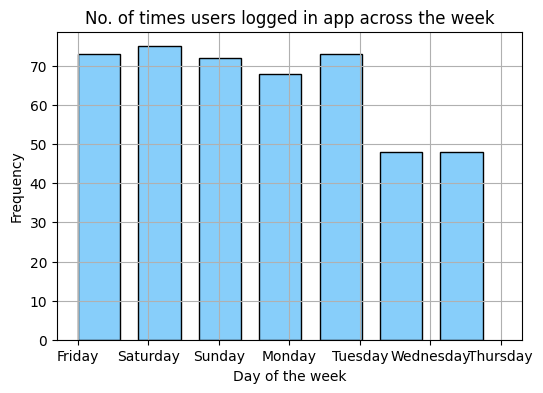

In [25]:
plt.style.use("default")
plt.figure(figsize=(6,4))
plt.hist(df_activity.day_of_the_week, bins = 7,
         width = 0.6, color = "lightskyblue", edgecolor = "black")


plt.xlabel("Day of the week")
plt.ylabel("Frequency")
plt.title("No. of times users logged in app across the week")
plt.grid(True)
plt.show()

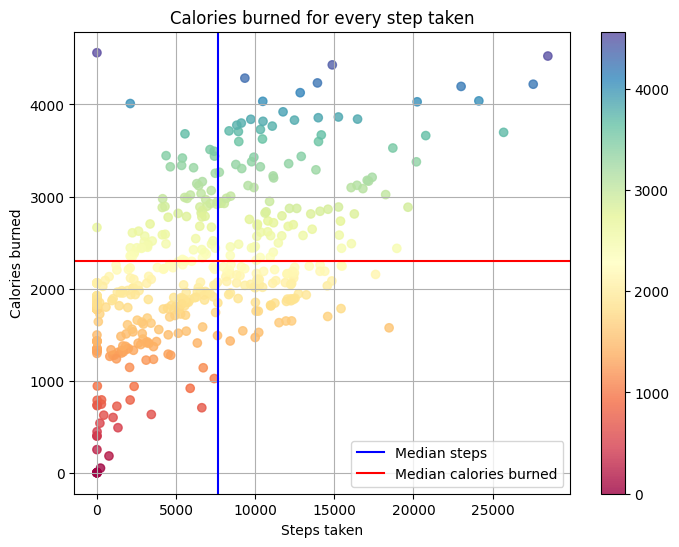

In [26]:
plt.style.use("default")
plt.figure(figsize=(8,6))
plt.scatter(df_activity.total_steps, df_activity.calories,
            alpha = 0.8, c = df_activity.calories,
            cmap = "Spectral")


median_calories = 2303
median_steps = 7637

plt.colorbar(orientation = "vertical")
plt.axvline(median_steps, color = "Blue", label = "Median steps")
plt.axhline(median_calories, color = "Red", label = "Median calories burned")
plt.xlabel("Steps taken")
plt.ylabel("Calories burned")
plt.title("Calories burned for every step taken")
plt.grid(True)
plt.legend()
plt.show()


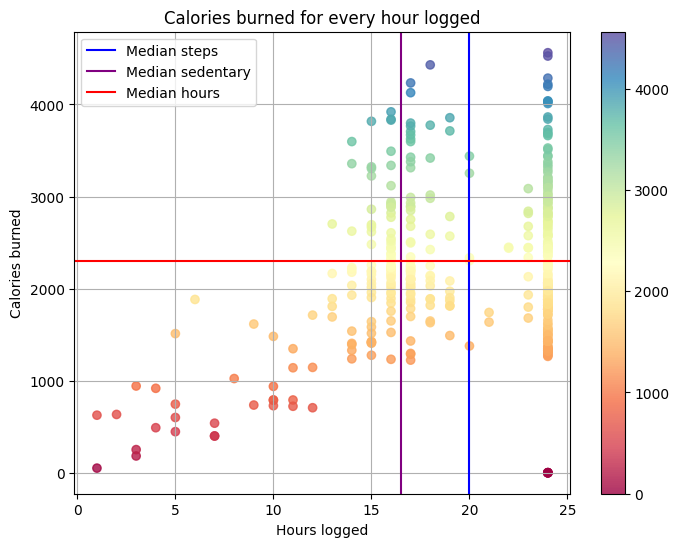

In [27]:
plt.style.use("default")
plt.figure(figsize=(8,6)) # Specify size of the chart
plt.scatter(df_activity.total_hours, df_activity.calories,
            alpha = 0.8, c = df_activity.calories,
            cmap = "Spectral")

# adding annotations and visuals
median_calories = 2303
median_hours = 20
median_sedentary = 991 / 60

plt.colorbar(orientation = "vertical")
plt.axvline(median_hours, color = "Blue", label = "Median steps")
plt.axvline(median_sedentary, color = "Purple", label = "Median sedentary")
plt.axhline(median_calories, color = "Red", label = "Median hours")
plt.xlabel("Hours logged")
plt.ylabel("Calories burned")
plt.title("Calories burned for every hour logged")
plt.legend()
plt.grid(True)
plt.show()

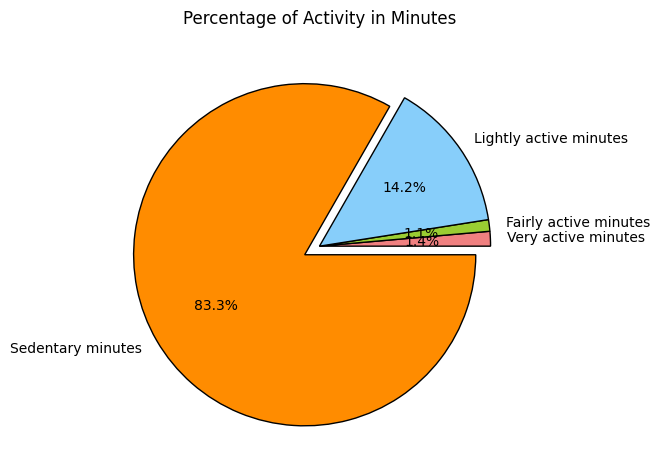

In [29]:
very_active_mins = df_activity["very_active_mins"].sum()
fairly_active_mins = df_activity["fairly_active_mins"].sum()
lightly_active_mins = df_activity["lightly_active_mins"].sum()
sedentary_mins = df_activity["sedentary_mins"].sum()

# plotting pie chart
slices = [very_active_mins, fairly_active_mins, lightly_active_mins, sedentary_mins]
labels = ["Very active minutes", "Fairly active minutes", "Lightly active minutes", "Sedentary minutes"]
colours = ["lightcoral", "yellowgreen", "lightskyblue", "darkorange"]
explode = [0, 0, 0, 0.1]
plt.style.use("default")
plt.pie(slices, labels = labels,
        colors = colours, wedgeprops = {"edgecolor": "black"},
        explode = explode, autopct = "%1.1f%%")
plt.title("Percentage of Activity in Minutes")
plt.tight_layout()
plt.show()